$F(x) = \begin{cases} 
0.4(x-1)^3 + 0.4, & x \in [0; 0.5) \\
0.3x + 0.2, & x \in [0.5; 1.5) \\
0.4(x-1)^3 + 0.6, & x \in [1.5; 2]
\end{cases}$

$F^{-1}(r) = \begin{cases}
\sqrt[3]{2.5r - 1} + 1, & r \in [0; 0.35) \\
\frac{10r - 2}{3}, & r \in [0.35; 0.65) \\
\sqrt[3]{2.5r - 1.5} + 1, & r \in [0.65; 1] \\
\end{cases}$

In [1]:
from random import seed

seed(1)

In [2]:
from random import uniform
from math import copysign


def cube_root(x):
    return copysign(abs(x) ** (1 / 3), x)


def func(x):
    if x < 0:
        return 0
    if x < 0.5:
        return 0.4 * (x - 1) ** 3 + 0.4
    elif x < 1.5:
        return 0.3 * x + 0.2
    elif x <= 2:
        return 0.4 * (x - 1) ** 3 + 0.6
    else:
        return 1


def generate(n):
    for _ in range(n):
        r = uniform(0, 1)

        if r < 0.35:
            yield cube_root(2.5 * r - 1) + 1
        elif r < 0.65:
            yield (10 * r - 2) / 3
        else:
            yield cube_root(2.5 * r - 1.5) + 1

Математическое ожидание: 1.0050190908366277
Дисперсия: 0.4868742721335282


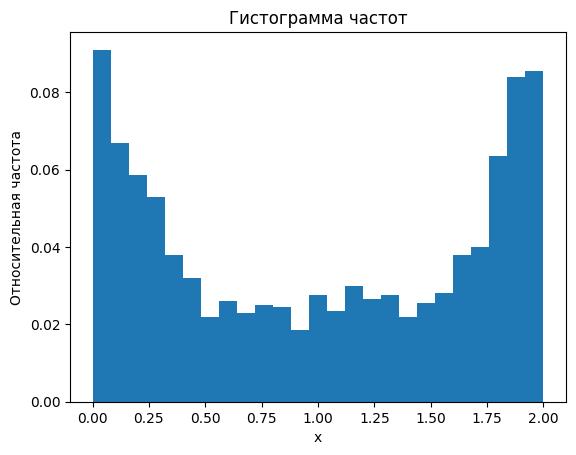

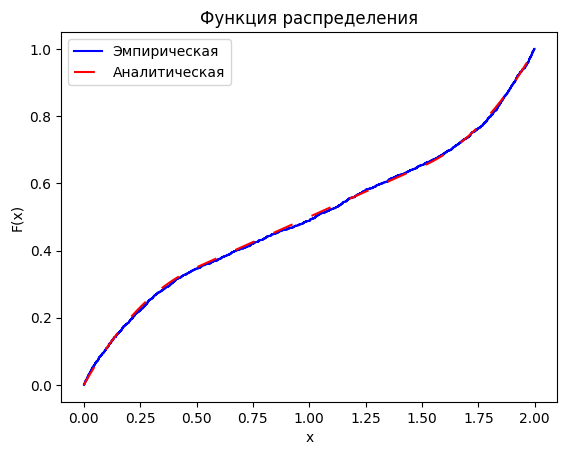

In [3]:
import matplotlib.pyplot as plt
import numpy as np

N = 2000
K = 25

X = list(generate(N))

hist = [0] * K
h = 2.0 / K

for x in X:
    index = int(x / h)
    if index == K:
        index = K - 1
    hist[index] += 1

hist_norm = [v / N for v in hist]

X_sorted = sorted(X)
F = []

for i in range(N):
    F.append((i + 1) / N)

mean = sum(X) / N
second_moment = sum(x**2 for x in X) / N
variance = second_moment - mean**2

print("Математическое ожидание:", mean)
print("Дисперсия:", variance)

x_hist = [i * h for i in range(K)]

plt.figure()
plt.bar(x_hist, hist_norm, width=h, align="edge")
plt.title("Гистограмма частот")
plt.xlabel("x")
plt.ylabel("Относительная частота")
plt.show()

plt.figure()
plt.step(X_sorted, F, where="post", color="blue", label="Эмпирическая")

x_theor = np.linspace(0, 2, N)
y_theor = [func(x) for x in x_theor]
plt.plot(
    x_theor,
    y_theor,
    color="red",
    linestyle="--",
    dashes=(10, 10),
    label="Аналитическая",
)

plt.title("Функция распределения")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()
plt.show()

In [4]:
import math


def kolmogorov(lambda_val, terms=10):
    s = 0
    for k in range(1, terms + 1):
        s += (-1) ** (k - 1) * math.exp(-2 * (k**2) * (lambda_val**2))
    return max(0, min(1, 2 * s))


D = 0

for i in range(N):
    dp = abs((i + 1) / N - func(X_sorted[i]))
    dm = abs(func(X_sorted[i]) - i / N)
    D = max(D, dp, dm)

lmb = D * N**0.5

print("D =", D)
print("λ =", lmb)
print("P(λ) =", kolmogorov(lmb))

D = 0.011799922236801597
λ = 0.5277085650139949
P(λ) = 0.943416133575303
